# Proyecto Deep Learning Spotify: Tarea 3 - Modelo 6: Red Widedeep

## Configuración del entorno

In [ ]:
%pip install -r ../requirements.txt

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping


sys.path.append(os.path.abspath('..'))
from models.T3_M6_red_widedeep import crear_modelo

In [2]:
df = pd.read_csv(r'..\data\data.csv')

df_limpio = df[
    (df['duration_ms'] > 40000) & 
    (df['speechiness'] < 0.90) & 
    (df['tempo'] > 0)
].copy()

cols_to_drop = ['popularity', 'id', 'name', 'artists', 'id_artists', 'release_date', 'mode']
X = df_limpio.drop(columns=cols_to_drop, errors='ignore')
y = df_limpio['popularity']

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [4]:
modelo_nn = crear_modelo(X_train_scaled.shape[1])

print("RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)")
modelo_nn.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      1,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 45)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         46 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,942 (50.55 KB)

 Trainable params: 12,558 (49.05 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 197.2688 - mae: 9.7461 - val_loss: 105.0594 - val_mae: 7.2978
Epoch 2/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 121.6922 - mae: 7.9860 - val_loss: 103.9627 - val_mae: 7.1759
Epoch 3/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 118.9196 - mae: 7.8860 - val_loss: 103.4918 - val_mae: 7.2402
Epoch 4/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 115.8538 - mae: 7.7613 - val_loss: 103.9976 - val_mae: 7.3226
Epoch 5/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 113.8374 - mae: 7.6809 - val_loss: 103.4070 - val_mae: 7.0435
Epoch 6/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 111.9934 - mae: 7.6282 - val_loss: 101.7635 - val_mae: 7.0770
Epoch 7/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 110.4964 - mae: 7.5569 - val_loss: 101.9945 - val_mae: 7.1250
Epoch 8/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 109.2459 - mae: 7.5184 - val_loss: 100.5415 - val_mae: 7.059

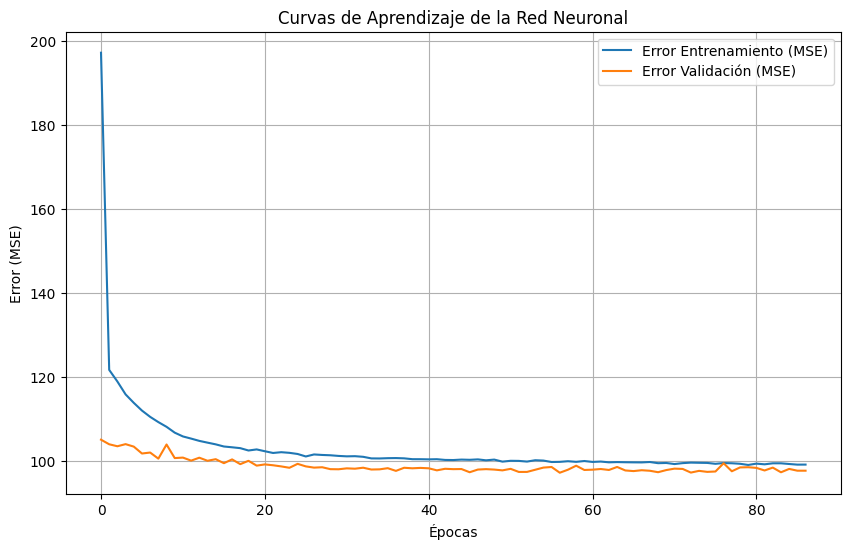

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(historia.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def evaluar_red(modelo, X_data, y_true, nombre_conjunto):
    y_pred = modelo.predict(X_data, verbose=0).flatten()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados en {nombre_conjunto} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print("EVALUACIÓN RED NEURONAL\n")

evaluar_red(modelo_nn, X_train_scaled, y_train, "ENTRENAMIENTO")
evaluar_red(modelo_nn, X_val_scaled, y_val, "VALIDACIÓN")
evaluar_red(modelo_nn, X_test_scaled, y_test, "TEST")

EVALUACIÓN RED NEURONAL

--- Resultados en ENTRENAMIENTO ---
MSE:  96.07
RMSE: 9.80
R²:   0.7936

--- Resultados en VALIDACIÓN ---
MSE:  96.63
RMSE: 9.83
R²:   0.7931

--- Resultados en TEST ---
MSE:  91.91
RMSE: 9.59
R²:   0.8005

